In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.plotting import view_img
from nilearn.glm import threshold_stats_img
from nilearn.reporting import get_clusters_table

# data_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE'
# fmriprep_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep'
# nilearn_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/nilearn_glm'
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep'
nilearn_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/nilearn_glm'

In [10]:
# fetch subject list
sub_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
sub_list.sort()
sub_list

['sub-01',
 'sub-02',
 'sub-03',
 'sub-05',
 'sub-06',
 'sub-07',
 'sub-08',
 'sub-10',
 'sub-11',
 'sub-12',
 'sub-15',
 'sub-16',
 'sub-21',
 'sub-22',
 'sub-23']

In [11]:
contrast_list = ['MovingPlaidMinusStaticPlaid','StaticPlaidMinusFixation']

Threshold: 5.19
  Cluster ID     X      Y     Z  Peak Stat Cluster Size (mm3)
0          1 -10.5 -106.5   5.5  10.369436              21376
1         1a  -6.5  -92.5 -16.5  10.272724                   
2         1b  15.5 -102.5   7.5  10.145212                   
3         1c -12.5  -94.5 -18.5   9.944391                   
4          2 -44.5  -78.5   1.5   7.746402                616
5          3  23.5  -70.5  61.5   7.450141                608
6          4 -14.5  -58.5  65.5   6.140920                832
7         4a -22.5  -60.5  57.5   5.780369                   


/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
/DATAPOOL/home/alexandresayal/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/nilearn/plotting/html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



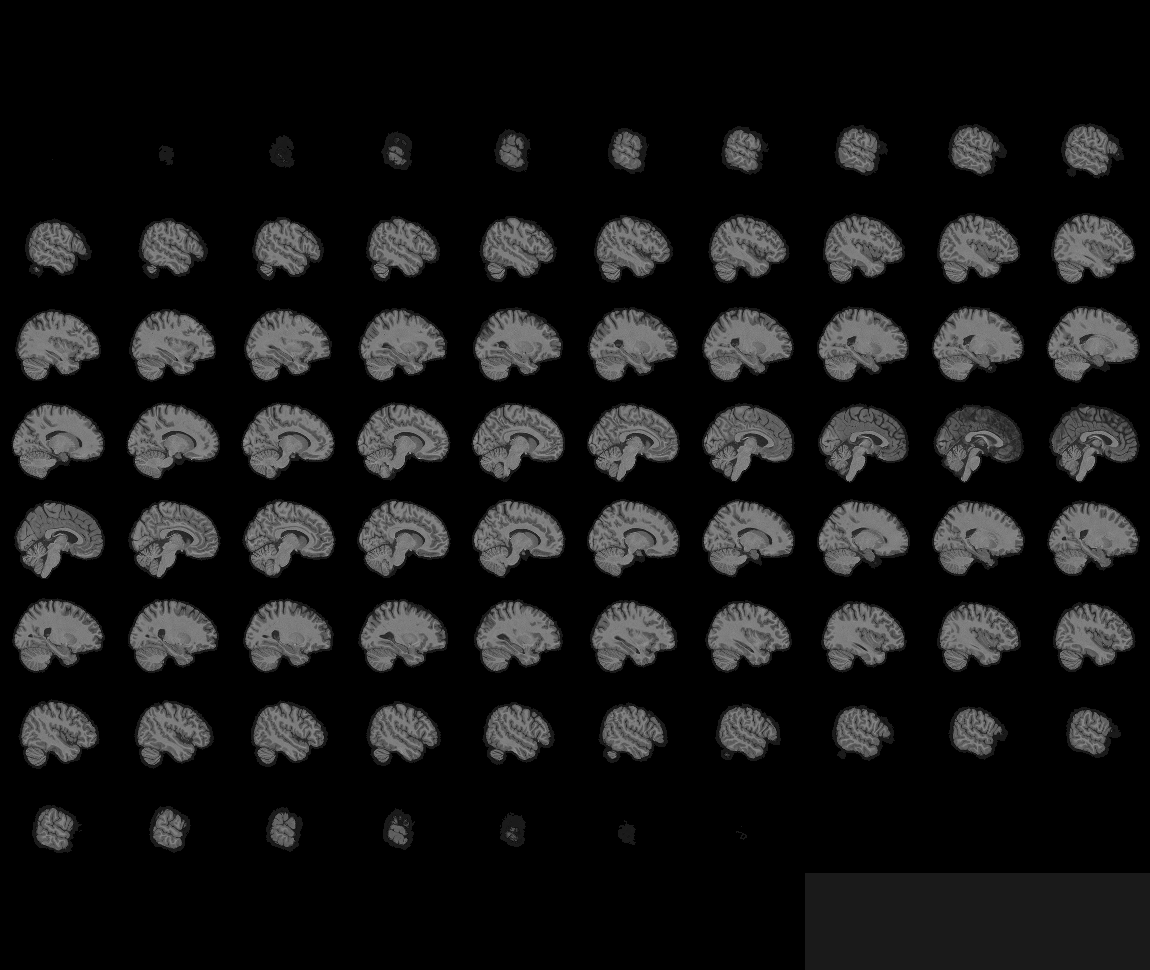
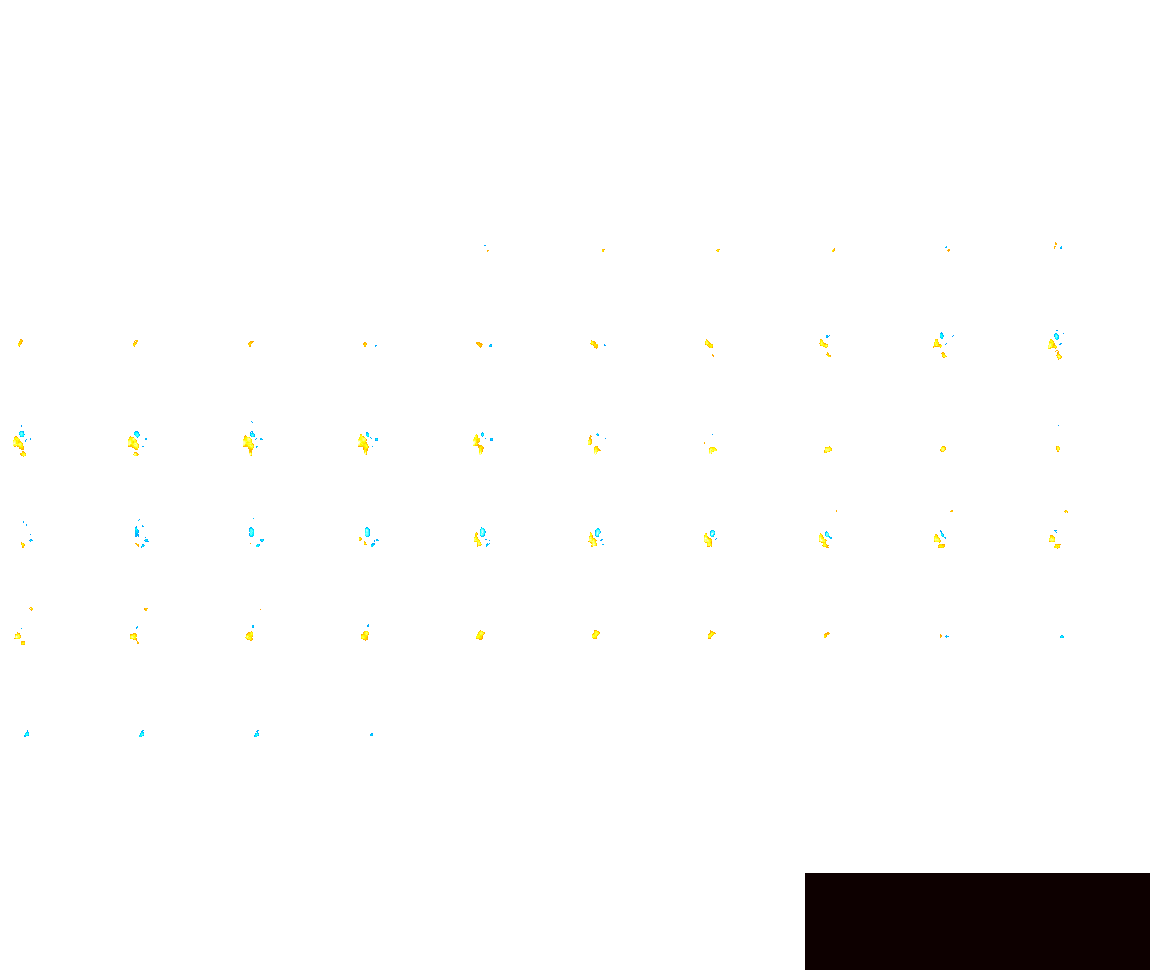

In [34]:
subID = sub_list[14]
cID = contrast_list[1]

# localizer tmap and plot
tmap = os.path.join(nilearn_dir,f'{subID}_task-loc_stat-t_con-{cID}.nii.gz')

clean_map, threshold = threshold_stats_img(
    tmap, alpha=0.05, height_control="bonferroni", cluster_threshold=50
)

print(f"Threshold: {threshold:.3g}")

table = get_clusters_table(tmap, threshold, 50)
print(table)

view_img(clean_map,
            title=f"{subID} {cID}",
            bg_img=os.path.join(fmriprep_dir,subID,'anat',f'{subID}_run-1_space-MNI152NLin2009cAsym_res-2_desc-preproc_T1w.nii.gz'),
            colorbar=True,
            threshold=threshold+1)

In [36]:
# initialize matrix with 12 columns, 15 rows, and fill with zeros
roi_ss_matrix = np.zeros((15,12)) # 15 subjects, 4 rois with 3 coordinates each. Left hMT+ | Right hMT | Left V1 | Right V1

roi_ss_matrix[0,:] =  [-46,-70,14, 46,-76,6,  -10,-98,0,   18,-96,2]
roi_ss_matrix[1,:] =  [-50,-70,14, 52,-68,8,  -14,-98,4,   14,-96,-8]
roi_ss_matrix[2,:] =  [-44,-62,0,  48,-64,0,  -4,-94,-6,   16,-82,-4]
roi_ss_matrix[3,:] =  [-46,-70,8,  48,-64,6,  -6,-92,-4,   18,-92,-8]
roi_ss_matrix[4,:] =  [-46,-66,12, 48,-68,6,  -12,-96,2,   16,-96,0]
roi_ss_matrix[5,:] =  [-46,-72,4,  54,-66,4,  -10,-88,-8,  20,-88,-4]
roi_ss_matrix[6,:] =  [-42,-78,12, 46,-72,4,  -8,-96,-4,   14,-86,-4]
roi_ss_matrix[7,:] =  [-46,-72,0,  52,-66,6,  -8,-90,-6,   16,-98,0]
roi_ss_matrix[8,:] =  [-44,-76,-4, 50,-68,-8, -18,-90,-8,  16,-84,-8]
roi_ss_matrix[9,:] =  [-42,-72,2,  48,-72,2,  -10,-98,-10, 16,-98,0]
roi_ss_matrix[10,:] = [-40,-80,-2, 50,-70,-4, -6,-100,6,   16,-94,2]
roi_ss_matrix[11,:] = [-40,-66,6,  44,-62,6,  -12,-100,4,  16,-92,2]
roi_ss_matrix[12,:] = [-50,-66,4,  52,-64,8,  -14,-84,-10, 12,-82,-6]
roi_ss_matrix[13,:] = [-44,-74,8,  50,-66,8,  -12,-84,-10, 14,-84,-6]
roi_ss_matrix[14,:] = [-50,-66,14, 48,-62,4,  -10,-90,0,   18,-94,2]

roi_ss_matrix


array([[ -46.,  -70.,   14.,   46.,  -76.,    6.,  -10.,  -98.,    0.,
          18.,  -96.,    2.],
       [ -50.,  -70.,   14.,   52.,  -68.,    8.,  -14.,  -98.,    4.,
          14.,  -96.,   -8.],
       [ -44.,  -62.,    0.,   48.,  -64.,    0.,   -4.,  -94.,   -6.,
          16.,  -82.,   -4.],
       [ -46.,  -70.,    8.,   48.,  -64.,    6.,   -6.,  -92.,   -4.,
          18.,  -92.,   -8.],
       [ -46.,  -66.,   12.,   48.,  -68.,    6.,  -12.,  -96.,    2.,
          16.,  -96.,    0.],
       [ -46.,  -72.,    4.,   54.,  -66.,    4.,  -10.,  -88.,   -8.,
          20.,  -88.,   -4.],
       [ -42.,  -78.,   12.,   46.,  -72.,    4.,   -8.,  -96.,   -4.,
          14.,  -86.,   -4.],
       [ -46.,  -72.,    0.,   52.,  -66.,    6.,   -8.,  -90.,   -6.,
          16.,  -98.,    0.],
       [ -44.,  -76.,   -4.,   50.,  -68.,   -8.,  -18.,  -90.,   -8.,
          16.,  -84.,   -8.],
       [ -42.,  -72.,    2.,   48.,  -72.,    2.,  -10.,  -98.,  -10.,
          16.,  -98.

In [38]:
#save matrix
np.savetxt(os.path.join(nilearn_dir,'group','roi_ss_matrix.txt'), roi_ss_matrix, delimiter='\t',
        fmt='%2i')